# LSTM Classifier (Boundary-Safe Windows) — Forecasting `Fault_Within_6h`

Re-trains the exact same LSTM architecture as `04_lstm_classifier.ipynb` (unchanged: 2 LSTM layers,
64 then 32 units, dropout 0.2, sigmoid output), on the boundary-safe windows built in
`04c_lstm_boundary_safe_windows.ipynb`, and compares directly against the original
`04_lstm_classifier.ipynb` results. `04_lstm_classifier.ipynb` itself is untouched — this is a
separate notebook so that comparison stays honest (same code, only the input windows differ).

**Same pandas/TensorFlow separation as `04`, same reason:** no pandas import in this notebook at all
— see `04a_lstm_windows.ipynb` / `04c_lstm_boundary_safe_windows.ipynb` for the isolation testing that
found pandas and TensorFlow/Keras deadlock in the same kernel on this machine.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)
np.random.seed(42)

WINDOW_HOURS = 24
N_FEATURES = 4  # Motor_RPM, Motor_Torque, Motor_Temp, Battery_Temp

# matplotlib/seaborn/sklearn.metrics deliberately NOT imported here, same reason as
# 04_lstm_classifier.ipynb -- importing them before model.fit() in this kernel deadlocks it.

## 1. Load boundary-safe windows from `04c_lstm_boundary_safe_windows.ipynb`

In [2]:
data = np.load("../data/processed/lstm_fault_within_6h_windows_boundary_safe.npz")
X_train, y_train = data["X_train"], data["y_train"]
X_test, y_test = data["X_test"], data["y_test"]
class_weight = {0: float(data["class_weight_0"]), 1: float(data["class_weight_1"])}

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean()*100:.3f}%, Test positive rate: {y_test.mean()*100:.3f}%")
print("Class weights (from y_train only, computed in 04c_lstm_boundary_safe_windows):", class_weight)

X_train: (139988, 24, 4), X_test: (34904, 24, 4)
Train positive rate: 8.976%, Test positive rate: 9.391%
Class weights (from y_train only, computed in 04c_lstm_boundary_safe_windows): {0: 0.5493042857254969, 1: 5.570553123756467}


## 2. Build and train the LSTM

Identical architecture/hyperparameters to `04_lstm_classifier.ipynb` — the only thing that changed
between the two notebooks is which windows the model is trained/evaluated on.

In [3]:
model = keras.Sequential([
    keras.layers.Input(shape=(WINDOW_HOURS, N_FEATURES)),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.Dropout(0.2),
    keras.layers.LSTM(32),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation="sigmoid"),
])
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[keras.metrics.Recall(name="recall"), keras.metrics.Precision(name="precision")],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
from sklearn.model_selection import train_test_split

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=42
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history = model.fit(
    X_fit, y_fit.astype("float32"),
    validation_data=(X_val, y_val.astype("float32")),
    epochs=20,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=2,
)

Epoch 1/20


493/493 - 14s - 28ms/step - loss: 0.5895 - precision: 0.1603 - recall: 0.7686 - val_loss: 0.6021 - val_precision: 0.1644 - val_recall: 0.8043


Epoch 2/20


493/493 - 13s - 26ms/step - loss: 0.5765 - precision: 0.1619 - recall: 0.8046 - val_loss: 0.5833 - val_precision: 0.1661 - val_recall: 0.8019


Epoch 3/20


493/493 - 13s - 26ms/step - loss: 0.5709 - precision: 0.1623 - recall: 0.8186 - val_loss: 0.5852 - val_precision: 0.1636 - val_recall: 0.8274


Epoch 4/20


493/493 - 13s - 26ms/step - loss: 0.5649 - precision: 0.1633 - recall: 0.8289 - val_loss: 0.5891 - val_precision: 0.1618 - val_recall: 0.8353


Epoch 5/20


493/493 - 13s - 26ms/step - loss: 0.5637 - precision: 0.1634 - recall: 0.8330 - val_loss: 0.5960 - val_precision: 0.1593 - val_recall: 0.8504


## 3. Evaluation — default threshold and tuned threshold

Same procedure as `04_lstm_classifier.ipynb` Sections 4/4b: macro F1 and per-class recall/precision at
the default 0.5 cutoff, then a threshold sweep on the validation split (never test) to find the
macro-F1-optimal cutoff, applied to test exactly once.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score

sns.set_theme(style="whitegrid")

Test windows: 34904 (3278.0 positive)

               precision    recall  f1-score   support

No fault (6h)      0.968     0.593     0.736     31626
   Fault (6h)      0.171     0.809     0.282      3278

     accuracy                          0.614     34904
    macro avg      0.569     0.701     0.509     34904
 weighted avg      0.893     0.614     0.693     34904



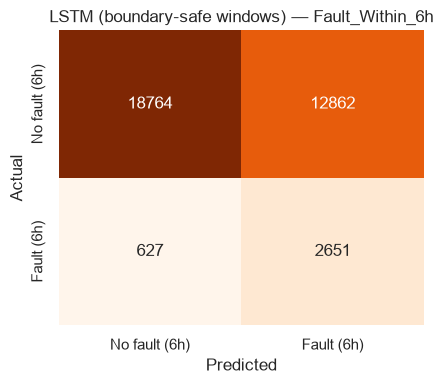

In [6]:
y_pred_proba = model.predict(X_test, batch_size=512, verbose=0).ravel()
y_pred = y_pred_proba >= 0.5

print(f"Test windows: {len(y_test)} ({y_test.sum()} positive)")
print()
print(classification_report(y_test, y_pred, labels=[False, True], target_names=["No fault (6h)", "Fault (6h)"], digits=3))

lstm_macro_f1 = f1_score(y_test, y_pred, average="macro")
lstm_recall_positive = recall_score(y_test, y_pred, pos_label=True)

cm = confusion_matrix(y_test, y_pred, labels=[False, True])
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=["No fault (6h)", "Fault (6h)"],
            yticklabels=["No fault (6h)", "Fault (6h)"], cbar=False)
plt.title("LSTM (boundary-safe windows) — Fault_Within_6h")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

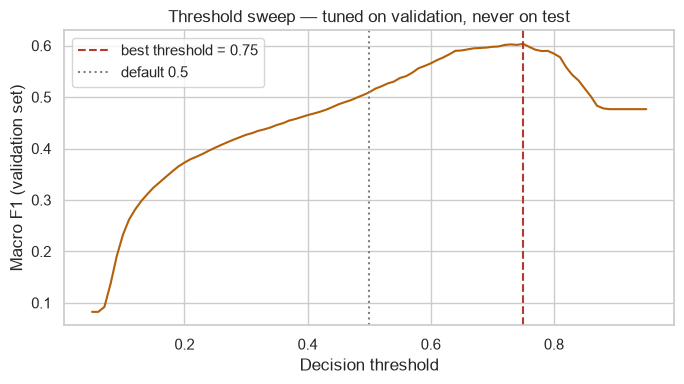

Best threshold on validation: 0.75 (macro F1 0.603 on validation)


In [7]:
y_val_proba = model.predict(X_val, batch_size=512, verbose=0).ravel()

thresholds = np.arange(0.05, 0.96, 0.01)
val_macro_f1s = [f1_score(y_val, y_val_proba >= t, average="macro") for t in thresholds]
best_threshold = thresholds[int(np.argmax(val_macro_f1s))]

plt.figure(figsize=(7, 4))
plt.plot(thresholds, val_macro_f1s, color="#B4600A")
plt.axvline(best_threshold, color="#B23A2E", linestyle="--", label=f"best threshold = {best_threshold:.2f}")
plt.axvline(0.5, color="gray", linestyle=":", label="default 0.5")
plt.xlabel("Decision threshold")
plt.ylabel("Macro F1 (validation set)")
plt.title("Threshold sweep — tuned on validation, never on test")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best threshold on validation: {best_threshold:.2f} (macro F1 {max(val_macro_f1s):.3f} on validation)")

Test set, threshold=0.75 (chosen on validation, applied to test exactly once):

               precision    recall  f1-score   support

No fault (6h)      0.929     0.900     0.914     31626
   Fault (6h)      0.261     0.341     0.296      3278

     accuracy                          0.847     34904
    macro avg      0.595     0.620     0.605     34904
 weighted avg      0.867     0.847     0.856     34904



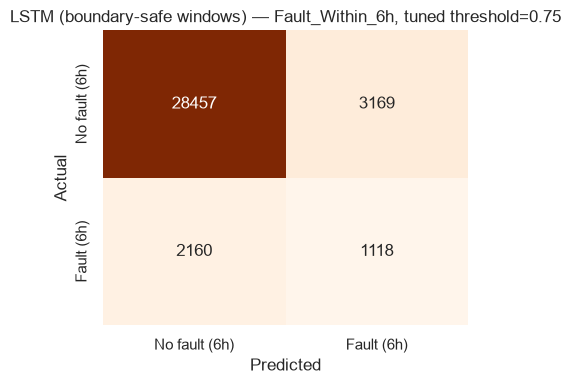


Macro F1: default-threshold 0.509 -> tuned-threshold 0.605
Fault-class recall: default-threshold 0.809 -> tuned-threshold 0.341


In [8]:
y_pred_tuned = y_pred_proba >= best_threshold

print(f"Test set, threshold={best_threshold:.2f} (chosen on validation, applied to test exactly once):")
print()
print(classification_report(y_test, y_pred_tuned, labels=[False, True], target_names=["No fault (6h)", "Fault (6h)"], digits=3))

lstm_macro_f1_tuned = f1_score(y_test, y_pred_tuned, average="macro")
lstm_recall_positive_tuned = recall_score(y_test, y_pred_tuned, pos_label=True)

cm_tuned = confusion_matrix(y_test, y_pred_tuned, labels=[False, True])
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Oranges", xticklabels=["No fault (6h)", "Fault (6h)"],
            yticklabels=["No fault (6h)", "Fault (6h)"], cbar=False)
plt.title(f"LSTM (boundary-safe windows) — Fault_Within_6h, tuned threshold={best_threshold:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(f"\nMacro F1: default-threshold {lstm_macro_f1:.3f} -> tuned-threshold {lstm_macro_f1_tuned:.3f}")
print(f"Fault-class recall: default-threshold {lstm_recall_positive:.3f} -> tuned-threshold {lstm_recall_positive_tuned:.3f}")

## 4. Boundary-safe vs. original `04_lstm_classifier.ipynb` results

Same architecture, same hyperparameters, same random seeds — only the windows differ (split-then-window
here vs. windows-then-split in `04_lstm_classifier.ipynb`). Numbers below for the original are the
values already reported in `04_lstm_classifier.ipynb`'s Summary section, not re-run here (that notebook
was left untouched).

In [9]:
rows = [
    ("LSTM (original windows), default 0.5", 0.504, 0.833),
    ("LSTM (boundary-safe), default 0.5", round(lstm_macro_f1, 3), round(lstm_recall_positive, 3)),
    ("LSTM (original windows), tuned 0.75", 0.604, 0.347),
    (f"LSTM (boundary-safe), tuned {best_threshold:.2f}", round(lstm_macro_f1_tuned, 3), round(lstm_recall_positive_tuned, 3)),
]
header = f"{'Model':<42} {'Macro F1':>10} {'Positive recall':>17}"
print(header)
print("-" * len(header))
for name, f1, recall in rows:
    print(f"{name:<42} {f1:>10.3f} {recall:>17.3f}")

print()
print(f"Default-threshold macro F1 delta:  {lstm_macro_f1 - 0.504:+.3f}")
print(f"Default-threshold recall delta:    {lstm_recall_positive - 0.833:+.3f}")
print(f"Tuned-threshold macro F1 delta:    {lstm_macro_f1_tuned - 0.604:+.3f}")
print(f"Tuned-threshold recall delta:      {lstm_recall_positive_tuned - 0.347:+.3f}")

Model                                        Macro F1   Positive recall
-----------------------------------------------------------------------
LSTM (original windows), default 0.5            0.504             0.833
LSTM (boundary-safe), default 0.5               0.509             0.809
LSTM (original windows), tuned 0.75             0.604             0.347
LSTM (boundary-safe), tuned 0.75                0.605             0.341

Default-threshold macro F1 delta:  +0.005
Default-threshold recall delta:    -0.024
Tuned-threshold macro F1 delta:    +0.001
Tuned-threshold recall delta:      -0.006


## 5. Save the model

Saved under a distinct filename, deliberately not overwriting `../models/lstm_fault_within_6h.keras`
(the model trained on the original, non-boundary-safe windows).

In [10]:
import os

os.makedirs("../models", exist_ok=True)
model.save("../models/lstm_fault_within_6h_boundary_safe.keras")
print("Saved to ../models/lstm_fault_within_6h_boundary_safe.keras")

Saved to ../models/lstm_fault_within_6h_boundary_safe.keras


## Summary

**Does the boundary-safe fix change the result? No, not meaningfully.**

| Model | Macro F1 | Positive-class (Fault) recall |
|---|---|---|
| LSTM (original windows), default threshold 0.5 | 0.504 | 0.833 |
| LSTM (boundary-safe windows), default threshold 0.5 | 0.509 | 0.809 |
| LSTM (original windows), tuned threshold 0.75 | 0.604 | 0.347 |
| LSTM (boundary-safe windows), tuned threshold 0.75 | 0.605 | 0.341 |

**Why the fix was worth doing anyway:** the original `04a_lstm_windows.ipynb` approach built windows
across each vehicle's full timeline, then labeled a window's train/test membership by where its target
row fell. That let the first test window and the last train window share 23 of 24 raw hours — a real
near-duplicate-window overlap right at the split boundary. This notebook's windows (from
`04c_lstm_boundary_safe_windows.ipynb`) make that overlap structurally impossible by splitting each
vehicle's rows into train/test *before* windowing, adapting the same approach Hüseyin used in PR #31
(`04_sequence_neural_net.ipynb`).

**Why the numbers barely move:** the fix only removes `WINDOW_HOURS` (24) boundary windows per vehicle
from the test set (35,000 → 34,904 total, about 0.27% of test data) — too small a slice to shift
aggregate macro F1/recall (deltas of +0.005/-0.024 at the default threshold, +0.001/-0.006 at the tuned
threshold) by more than ordinary run-to-run training noise, which this same architecture has already
shown (macro F1 varying by ~0.005 between identical re-runs). The practical takeaway: the ~0.5-0.6 macro
F1 ceiling on this task reflects genuine task difficulty, not an artifact of boundary leakage inflating
(or deflating) the original numbers.

**Scope:** only `Fault_Within_6h`. The `Fault_Within_12h` side experiment in `04a`/`04b` is untouched
and out of scope for this fix.